# **DecodeLabs Project 2: Simple Linear Regression on Housing Prices**

**Importing Relevant Libraries**

In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

**Data Sourcing**

In [20]:
california = fetch_california_housing(as_frame=True)
df = california.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Dataset Glossary & Feature Definitions** 

1. **MedInc** - Median Income
2. **HouseAge** - Median House Age
3. **AveRooms** - Average Rooms
4. **AveBedrms** - Average Bedrooms
5. **Population** - Block Population
6. **AveOccup** - Average Occupancy
7. **MedHouseVal** - Median House Value (Target)

**Data Preprocessing**

Feature Selection

In [22]:
selected_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
X = df[selected_features]
y = df['MedHouseVal']

**Splitting our Data**

We would be using 80% of our data to train the model, and the rest to test it.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Normalization

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Building our Linear Regression Model**

In [25]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Evaluating our Model's performance**

In [26]:
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation Metrics:")
print(f"--------------------------")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (Accuracy): {r2:.4f}")

Model Evaluation Metrics:
--------------------------
Root Mean Squared Error (RMSE): 0.8014
R-squared Score (Accuracy): 0.5099


**Conclusion**

* An R-squared value of *(0.5099)* indicates a moderate fit. It proves that variables like income and room count definitely influence housing prices, but they do not tell the whole story. 
<nb>\
<nb>\
<nb>
* In the California dataset, the target variable (MedHouseVal) is expressed in hundreds of thousands of dollars *($100,000)*. Therefore, an RMSE of *0.8014* means our model's predictions are off by an average of roughly *$80,140*.

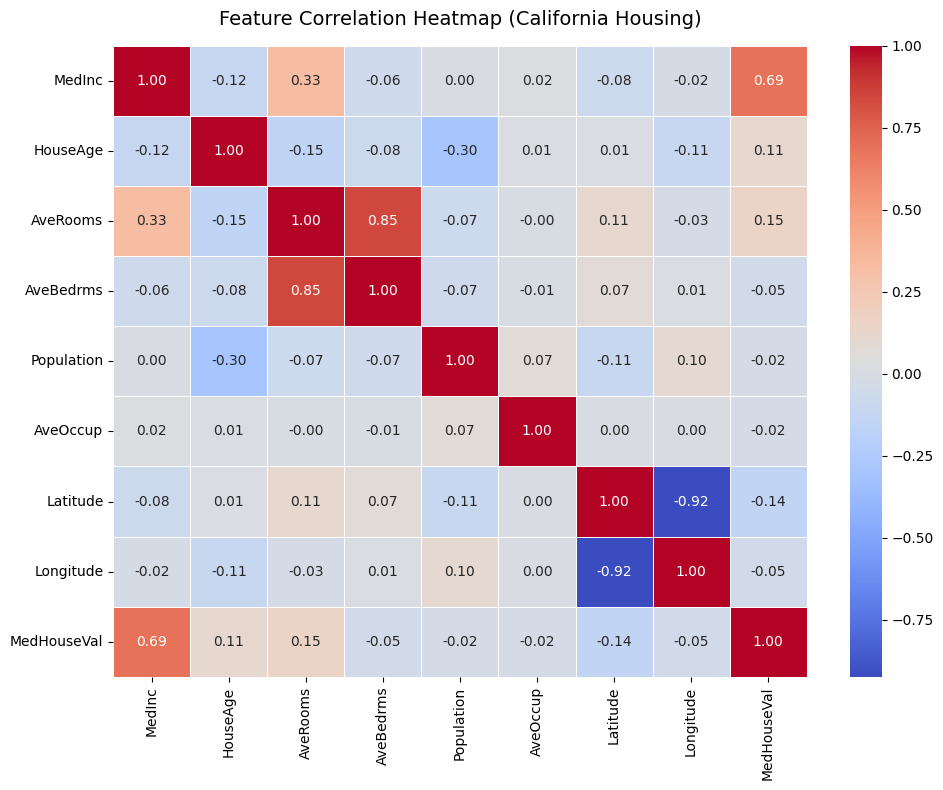

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure size
plt.figure(figsize=(10, 8))

# Generate the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the correlation numbers in each cell
    cmap='coolwarm',     # Red for positive correlation, blue for negative
    fmt=".2f",           # Round numbers to 2 decimal places
    linewidths=0.5       # Add small spacing between cells
)

# Add titles and formatting
plt.title('Feature Correlation Heatmap (California Housing)', fontsize=14, pad=15)
plt.tight_layout()

# Display the plot
plt.show()


**Correlation Analysis & Feature Insights**\
\
Based on the generated correlation heatmap, Median Income (MedInc) exhibits the strongest positive linear relationship with housing prices, with a correlation coefficient of approximately 0.69. \
This indicates that neighborhood wealth is the primary economic driver of property values in this dataset.\
Conversely, structural attributes like Average Rooms (AveRooms) and Average Bedrooms (AveBedrms) show a high internal correlation with each other. \
This introduced multicollinearity into our linear regression model, meaning they provide redundant structural information.\
Finally, the negative correlation found in the geographic coordinates (Latitude and Longitude) mathematically captures California's real estate landscape, where property values heavily increase as you move closer to high-density, coastal economic hubs